In [ ]:
import numpy as np
from pyrokinetics import Pyro, PyroHypercube
from pathlib import Path

In [ ]:
project = "MTM_MFAMILY_CSD3"
#cases = ["MTM_2d_Model1","MTM_2d_Model2","MTM_2d_Model3","MTM_3d_Model1","MTM_3d_Model2","MTM_3d_Model2_1","MTM_4d_Model1","MTM_4d_Model1_1"]
cases = ["MTM_2d_Model1"]
GYRO_DATA = Path("/mnt/data/Gyrokinetic_Simulations")

In [ ]:
pyro_cube_dict = {}

for case in cases:
    gftm_version = ["m3", "m5", "m7", "m9"]
    pyro_cube_sub_dict = {}

    for version in gftm_version:
        Pyro_cube_json = (
            GYRO_DATA / "GFTM" / "Runs" / project / case / version / "pyro_cube" / "pyroscan.json"
        )
        Pyro_cube_net_cdf = (
            GYRO_DATA / "GFTM" / "Runs" / project / case / version / "pyro_cube" / "cube.nc"
        )

        pyro_cube = PyroHypercube(
            pyroscan_json=Pyro_cube_json,
            load_base_pyro=True,
        )
        pyro_cube.load_gk_output(netcdf_file=Pyro_cube_net_cdf)

        pyro_cube_sub_dict[version] = pyro_cube

    pyro_cube_dict[case] = pyro_cube_sub_dict



In [ ]:
gs2_cube_dict = {}
for case in cases:
    gs2_cube_json = GYRO_DATA / "GS2" / "Runs"/ "MTMdata_CSD3" / case / "pyro_cube_avg" /   "pyroscan.json"
    gs2_cube_net_cdf = GYRO_DATA / "GS2" / "Runs" / "MTMdata_CSD3" / case / "pyro_cube_avg" /  "cube.nc"
    gs2_cube = PyroHypercube(pyroscan_json=gs2_cube_json, load_base_pyro=True)
    gs2_cube.load_gk_output(netcdf_file=gs2_cube_net_cdf)
    gs2_cube_dict[case] = gs2_cube

In [ ]:
def to_float(x):
    """
    Convert plain scalars, numpy scalars, or pint quantities to float.
    """
    if hasattr(x, "item"):
        x = x.item()
    if hasattr(x, "magnitude"):
        return float(x.magnitude)
    return float(x)

def integrate_theta(da):
    """Integrate a one-dimensional DataArray over theta."""
    da = da.sortby("theta")

    return float(
        np.trapezoid(
            y=np.asarray(da.values),
            x=np.asarray(da.theta.values),
        )
    )

def calculate_eigenfunction_properties(
    da,
    theta_extent=18 * np.pi,
    normalize=True,
):
    da = (
        da
        .squeeze(drop=True)
        .sortby("theta")
        .where(np.abs(da.theta) <= theta_extent, drop=True)
    )

    if normalize:
        peak = to_float(np.abs(da).max())

        if peak == 0:
            raise ValueError("Cannot normalize a zero eigenfunction.")

        da = da / peak

    positive_theta = da.where(da.theta > 0, drop=True)
    negative_theta = da.where(da.theta < 0, drop=True)

    positive_integral = integrate_theta(positive_theta)
    negative_integral = integrate_theta(negative_theta)

    func_odd = positive_integral * negative_integral < 0

    neg = (
        (func_odd and positive_integral < 0)
        or
        ((not func_odd) and positive_integral > 0)
    )

    average_amplitude = (
        abs(positive_integral) + abs(negative_integral)
    ) / 2

    return {
        "odd": bool(func_odd),
        "neg": bool(neg),
        "avg_amp": float(average_amplitude),
        "pos_sum": float(positive_integral),
        "neg_sum": float(negative_integral),
    }


def classify_mode(gftm_phi):

    gftm_phi = np.real(gftm_phi)

    # Reject zero GFTM eigenfunctions
    try:
        gftm_peak = to_float(np.abs(gftm_phi).max())
    except (ValueError, TypeError):
        return False

    if not np.isfinite(gftm_peak) or gftm_peak == 0:
        return False

    try:
        properties = calculate_eigenfunction_properties(gftm_phi)
    except (ValueError, TypeError):
        return False

    return properties["odd"]

In [ ]:
gftm_data_dict = {version: [] for version in gftm_version}
gs2_data = []

for case in cases:
    samples = gs2_cube_dict[case]["sample"].values

    for sample in samples:

        # Only use converged GS2 points
        tolerance = (
            gs2_cube_dict[case]["growth_rate_tolerance"]
            .sel(sample=sample)
            .values
            .item()
        )

        if tolerance >= 0.01:
            continue

        # added check to see if gs2 eigenfunctions are actually MTMs
        eigenfunction = (
                    gs2_cube_dict[case]["eigenfunctions"]
                    .sel(sample=sample, field="phi")
                )

        if not classify_mode(eigenfunction):
                    continue

        gs2_growth_rate = (
            gs2_cube_dict[case]["growth_rate"]
            .sel(sample=sample)
            .values
            .item()
        )

        gs2_data.append(gs2_growth_rate)

        for version in gftm_version:
            match = None

            for mode in pyro_cube_dict[case][version]["mode"].values:
                eigenfunction = (
                    pyro_cube_dict[case][version]["eigenfunctions"]
                    .sel(sample=sample, mode=mode, field="phi")
                )

                if not classify_mode(eigenfunction):
                    continue

                match = to_float(
                    pyro_cube_dict[case][version]["growth_rate"]
                    .sel(sample=sample, mode=mode)
                )
                break

            gftm_data_dict[version].append(match)

/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Proje

In [ ]:
gs2_cube_dict["MTM_2d_Model1"].gk_output

<pyrokinetics.PyroScanGKOutput>
(Wraps <xarray.Dataset>) Size: 14MB
Dimensions:                 (sample: 200, ky: 1, field: 2, theta: 2177,
                             species: 3)
Coordinates:
  * sample                  (sample) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    electron_temp_gradient  (sample) float64 2kB [1/lref_minor_radius] 4.547 ...
    shat                    (sample) float64 2kB [] 1.02 2.339 ... 1.767 4.687
    sample_name             (sample) <U13 10kB 'iteration_0' ... 'iteration_199'
  * field                   (field) <U4 32B 'phi' 'apar'
  * species                 (species) <U8 96B 'ion1' 'ion2' 'electron'
  * ky                      (ky) float64 8B 0.7024
  * theta                   (theta) float64 17kB -53.41 -53.36 ... 53.36 53.41
Data variables:
    growth_rate             (sample, ky) float64 2kB [vref_nrl/lref_minor_radius] ...
    mode_frequency          (sample, ky) float64 2kB [vref_nrl/lref_minor_radius] ...
    eigenfunctions          (sample, f

In [ ]:
gftm_data_dict = {version: [] for version in gftm_version}
gs2_data = []

for case in cases:
    samples = gs2_cube_dict.gk_output[case]["sample"].values

    for sample in samples:

        # Only use converged GS2 points
        tolerance = (
            gs2_cube_dict.gk_output[case]["growth_rate_tolerance"]
            .sel(sample=sample)
            .values
            .item()
        )

        if tolerance >= 0.01:
            continue

        # added check to see if gs2 eigenfunctions are actually MTMs
        eigenfunction = (
                    gs2_cube_dict.gk_output[case]["eigenfunctions"]
                    .sel(sample=sample, field="phi")
                )

        if not classify_mode(eigenfunction):
                    continue

        gs2_growth_rate = (
            gs2_cube_dict.gk_output[case]["growth_rate"]
            .sel(sample=sample)
            .values
            .item()
        )

        gs2_data.append([gs2_growth_rate)

        for version in gftm_version:
            match = None

            for mode in pyro_cube_dict.gk_output[case][version]["mode"].values:
                eigenfunction = (
                    pyro_cube_dict[case][version]["eigenfunctions"]
                    .sel(sample=sample, mode=mode, field="phi")
                )

                if not classify_mode(eigenfunction):
                    continue

                match = to_float(
                    pyro_cube_dict.gk_output[case][version]["growth_rate"]
                    .sel(sample=sample, mode=mode)
                )
                break

            gftm_data_dict[version].append(match)

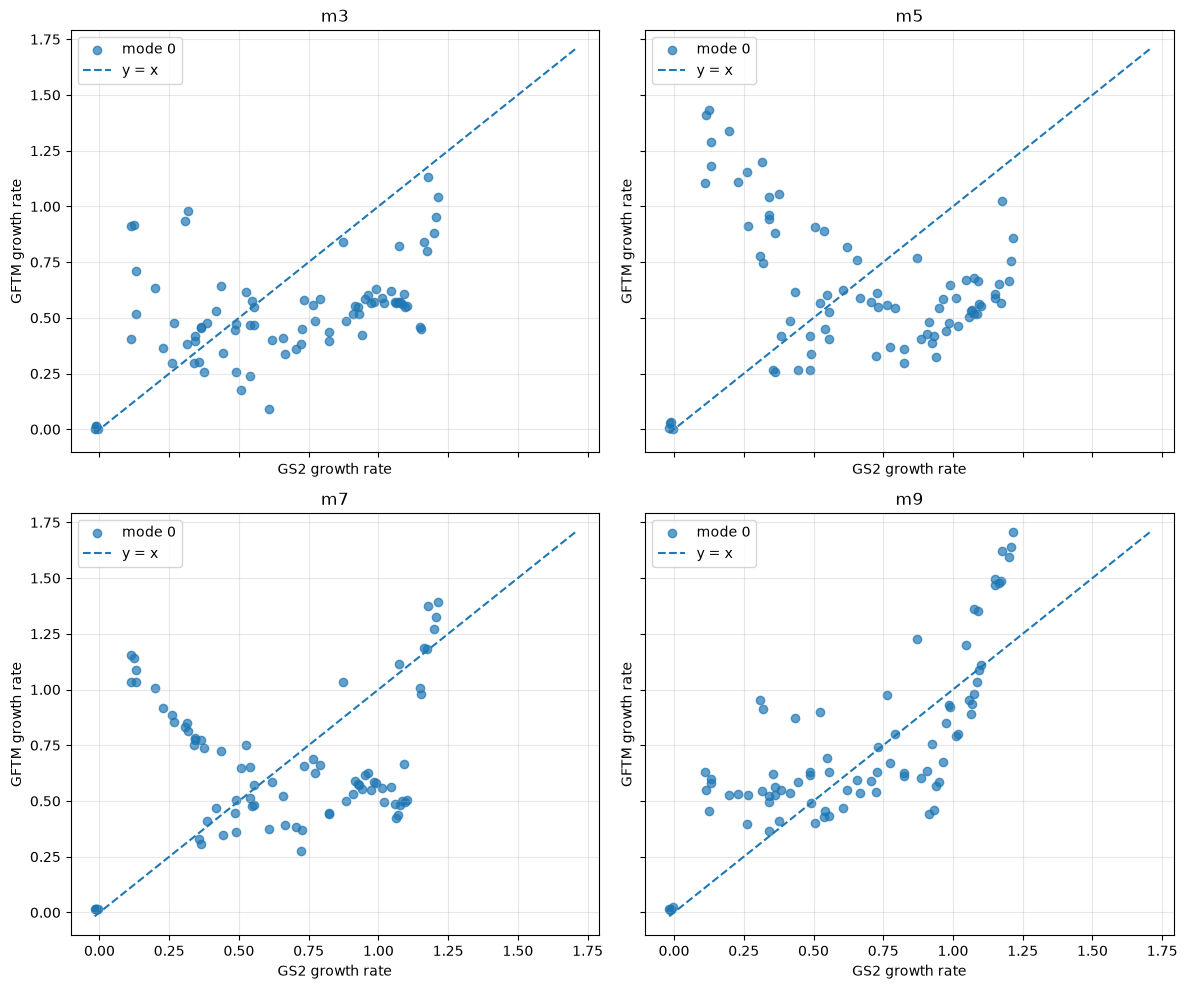

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

# ------------------------------------------------------------
# Find common limits, ignoring points where no MTM was found
# ------------------------------------------------------------

all_gftm = []

for version in gftm_data_dict:
    for gftm in gftm_data_dict[version]:

        if gftm is None:
            continue

        gftm_rate = gftm

        all_gftm.append(
            np.asarray(gftm_rate).squeeze().item()
        )

lims = [
    min(min(gs2_data), min(all_gftm)),
    max(max(gs2_data), max(all_gftm)),
]


# ------------------------------------------------------------
# Plot each GFTM version
# ------------------------------------------------------------

for ax, version in zip(axes, gftm_data_dict):

    gftm_growth = []
    gs2_growth = []
    modes = []

    for gs2, gftm in zip(gs2_data, gftm_data_dict[version]):

        # No MTM found for this point
        if gftm is None:
            continue

        gftm_rate = gftm

        gs2_rate = np.asarray(gs2).squeeze().item()
        gftm_rate = np.asarray(gftm_rate).squeeze().item()

        # Ignore invalid values
        if not np.isfinite(gs2_rate) or not np.isfinite(gftm_rate):
            continue

        gs2_growth.append(gs2_rate)
        gftm_growth.append(gftm_rate)
        modes.append(mode)

    gs2_growth = np.asarray(gs2_growth)
    gftm_growth = np.asarray(gftm_growth)
    modes = np.asarray(modes)

    # --------------------------------------------------------
    # Plot each mode
    # --------------------------------------------------------

    if len(modes) > 0:

        unique_modes = np.unique(modes)

        for mode in unique_modes:

            mask = modes == mode

            ax.scatter(
                gs2_growth[mask],
                gftm_growth[mask],
                label=f"mode {mode}",
                alpha=0.7,
            )

    # y = x reference line
    ax.plot(
        lims,
        lims,
        "--",
        label="y = x",
    )

    ax.set_title(version)
    ax.set_xlabel("GS2 growth rate")
    ax.set_ylabel("GFTM growth rate")
    ax.grid(True, alpha=0.3)
    ax.legend()

    #ax.set_xscale("log")
    #ax.set_yscale("log")


plt.tight_layout()
plt.show()

In [ ]:
gftm_data_dict = {version: [] for version in gftm_version}
gs2_data = []

for case in cases:
    for sample in gs2_cube_dict[case]["sample"].values:

        tolerance = to_float(
            gs2_cube_dict[case]["growth_rate_tolerance"].sel(sample=sample)
        )
        if tolerance >= 0.01:
            continue

        gs2_eigenfunction = (
            gs2_cube_dict[case]["eigenfunctions"].sel(sample=sample, field="phi")
        )
        if not classify_mode(gs2_eigenfunction):
            continue

        gs2_growth_rate = to_float(
            gs2_cube_dict[case]["growth_rate"].sel(sample=sample)
        )

        matches = {}

        for version in gftm_version:

            mtms = []

            for mode in pyro_cube_dict[case][version]["mode"].values:

                eigenfunction = (
                    pyro_cube_dict[case][version]["eigenfunctions"]
                    .sel(sample=sample, mode=mode, field="phi")
                )

                if not classify_mode(eigenfunction):
                    continue

                growth_rate = to_float(
                    pyro_cube_dict[case][version]["growth_rate"]
                    .sel(sample=sample, mode=mode)
                )

                if np.isfinite(growth_rate):
                    mtms.append((mode, growth_rate))

            if not mtms:
                matches[version] = None
                continue

            dominant_mode = max(mtms, key=lambda item: item[1])[0]
            mode, growth_rate = min(
                mtms, key=lambda item: abs(item[1] - gs2_growth_rate)
            )

            matches[version] = {
                "growth_rate": growth_rate,
                "mode": mode,
                "dominant": mode == dominant_mode,
            }

        gs2_data.append(gs2_growth_rate)

        for version, match in matches.items():
            gftm_data_dict[version].append(match)

/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Proje

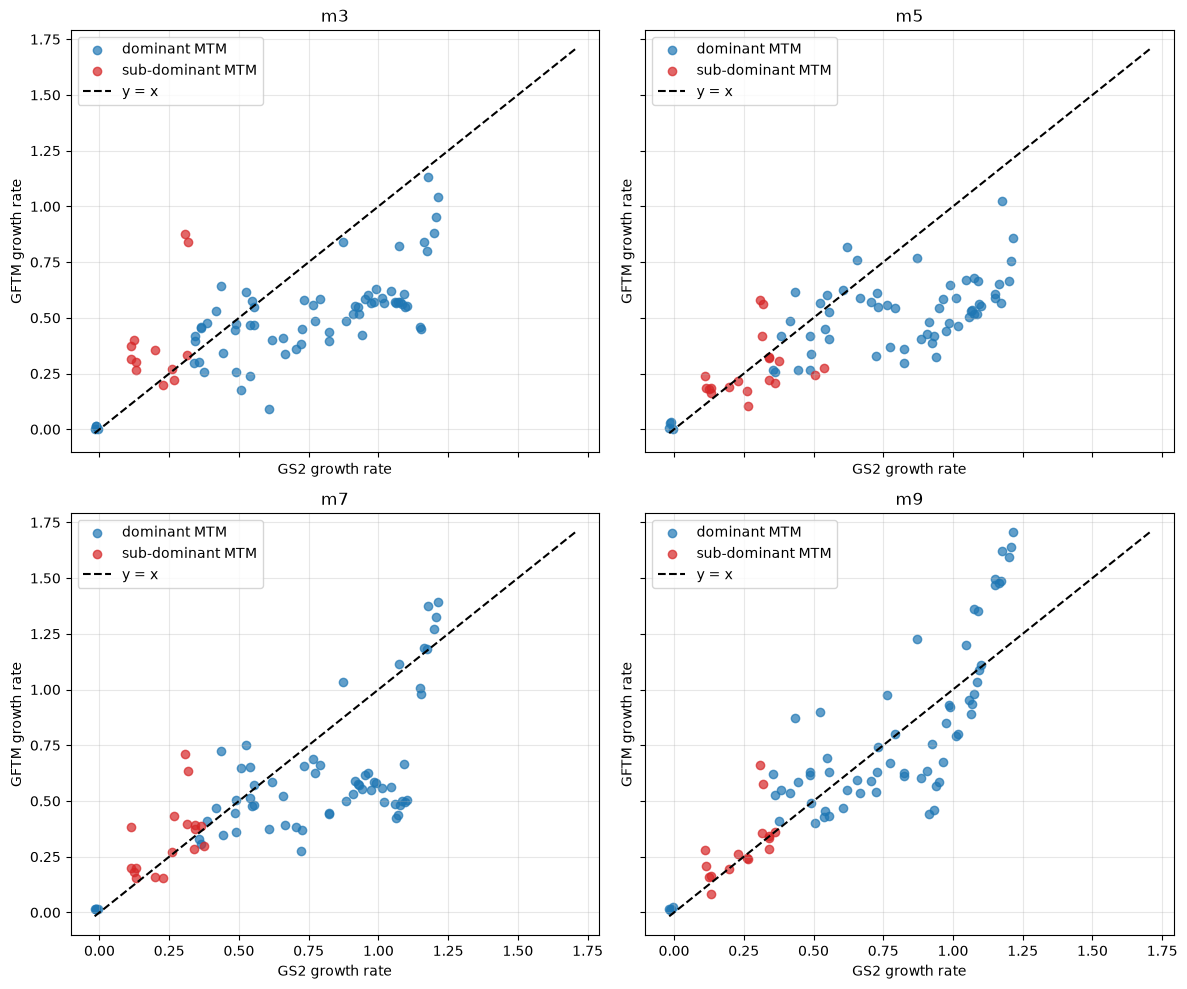

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

all_gftm = [
    match["growth_rate"]
    for version in gftm_data_dict
    for match in gftm_data_dict[version]
    if match is not None and np.isfinite(match["growth_rate"])
]

if not all_gftm:
    raise ValueError("No MTM matches found in any GFTM version.")

lims = [
    min(min(gs2_data), min(all_gftm)),
    max(max(gs2_data), max(all_gftm)),
]

for ax, version in zip(axes, gftm_data_dict):

    gs2_growth, gftm_growth, dominant = [], [], []

    for gs2_rate, match in zip(gs2_data, gftm_data_dict[version]):

        if match is None:
            continue

        if not (np.isfinite(gs2_rate) and np.isfinite(match["growth_rate"])):
            continue

        gs2_growth.append(gs2_rate)
        gftm_growth.append(match["growth_rate"])
        dominant.append(match["dominant"])

    gs2_growth = np.asarray(gs2_growth)
    gftm_growth = np.asarray(gftm_growth)
    dominant = np.asarray(dominant, dtype=bool)

    if gs2_growth.size:
        ax.scatter(
            gs2_growth[dominant],
            gftm_growth[dominant],
            color="tab:blue",
            alpha=0.7,
            label="dominant MTM",
        )
        ax.scatter(
            gs2_growth[~dominant],
            gftm_growth[~dominant],
            color="tab:red",
            alpha=0.7,
            label="sub-dominant MTM",
        )

    ax.plot(lims, lims, "--", color="k", label="y = x")

    ax.set_title(version)
    ax.set_xlabel("GS2 growth rate")
    ax.set_ylabel("GFTM growth rate")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

GS2_TOL_MAX  = 0.01
THETA_EXTENT = 18 * np.pi   # note: GFTM theta only spans +/- 9*pi, so this never truncates


def classify_parity_grid(eig, theta_extent=THETA_EXTENT):
    """
    Vectorised form of `classify_mode`, applied to a whole (sample, mode) grid.

    Same test as `calculate_eigenfunction_properties`: take Re(phi), split the
    theta integral about theta = 0, and call the mode odd (tearing parity -> MTM)
    when the two halves have opposite sign.

    Returns an object array of "MTM" / "KBM" / None, shape (sample, mode).
    None means the eigenfunction was zero or non-finite -- unlike `classify_mode`,
    those are dropped rather than being treated as even.
    """
    phi = eig.sel(field="phi").squeeze(drop=True).sortby("theta")
    phi = phi.where(np.abs(phi.theta) <= theta_extent, drop=True)
    phi = phi.transpose("sample", "theta", "mode")

    theta  = np.asarray(phi.theta.values, dtype=float)
    values = np.real(np.asarray(phi.values, dtype=complex))   # (sample, theta, mode)

    peak = np.nanmax(np.abs(values), axis=1)                  # (sample, mode)
    good = np.isfinite(peak) & (peak > 0)

    pos, neg = theta > 0, theta < 0
    pos_int = np.trapezoid(values[:, pos, :], theta[pos], axis=1)
    neg_int = np.trapezoid(values[:, neg, :], theta[neg], axis=1)

    odd = (pos_int * neg_int) < 0

    labels = np.full(peak.shape, None, dtype=object)
    labels[good &  odd] = "MTM"
    labels[good & ~odd] = "KBM"
    return labels


def _scan_coords(cube):
    """Numeric coordinates that vary over `sample` (the hypercube scan parameters)."""
    return {
        name: np.asarray(coord.values, dtype=float)
        for name, coord in cube.coords.items()
        if coord.dims == ("sample",)
        and np.issubdtype(np.asarray(coord.values).dtype, np.number)
    }


def build_mode_table(cases, gftm_version, pyro_cube_dict, gs2_cube_dict,
                    gs2_tol_max=GS2_TOL_MAX):
    """
    One row per (case, version, sample, mode). Every mode is kept -- no
    closest-to-GS2 selection, no parity filtering, only the GS2 convergence cut.
    """
    rows = []

    for case in cases:
        gs2 = gs2_cube_dict[case]

        gs2_gamma = np.asarray(gs2["growth_rate"].squeeze(drop=True).values, dtype=float)
        gs2_tol   = np.asarray(gs2["growth_rate_tolerance"].squeeze(drop=True).values, dtype=float)
        converged = gs2_tol < gs2_tol_max
        coords    = _scan_coords(gs2)

        for version in gftm_version:
            cube = pyro_cube_dict[case][version]

            gamma = np.asarray(
                cube["growth_rate"].squeeze(drop=True).transpose("sample", "mode").values,
                dtype=float,
            )
            omega = np.asarray(
                cube["mode_frequency"].squeeze(drop=True).transpose("sample", "mode").values,
                dtype=float,
            )
            ky     = np.asarray(cube["ky"].values, dtype=float).ravel()[0]
            labels = classify_parity_grid(cube["eigenfunctions"])
            modes  = np.asarray(cube["mode"].values)

            for si in range(gamma.shape[0]):
                if not converged[si]:
                    continue

                for mi in range(gamma.shape[1]):
                    if labels[si, mi] is None:      # zero / non-finite eigenfunction
                        continue

                    row = {
                        "case":       case,
                        "version":    version,
                        "sample":     si,
                        "mode":       int(modes[mi]),
                        "parity":     labels[si, mi],
                        "ky":         ky,
                        "gs2_gamma":  gs2_gamma[si],
                        "gftm_gamma": gamma[si, mi],
                        "gftm_omega": omega[si, mi],
                    }
                    row.update({name: vals[si] for name, vals in coords.items()})
                    rows.append(row)

    return pd.DataFrame(rows)


modes_df = build_mode_table(cases, gftm_version, pyro_cube_dict, gs2_cube_dict)

/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/tmp/ipykernel_237691/1136270485.py:27: RuntimeWarning: All-NaN slice encountered
  peak = np.nanmax(np.abs(values), axis=1)                  # (sample, mode)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/tmp/ipykernel_237691/1136270485.py:27: RuntimeWarning: All-NaN slice encountered
  peak = np.nanmax(np.abs(values), axis

[note] dropped 1647 of 14822 rows with a non-positive growth rate


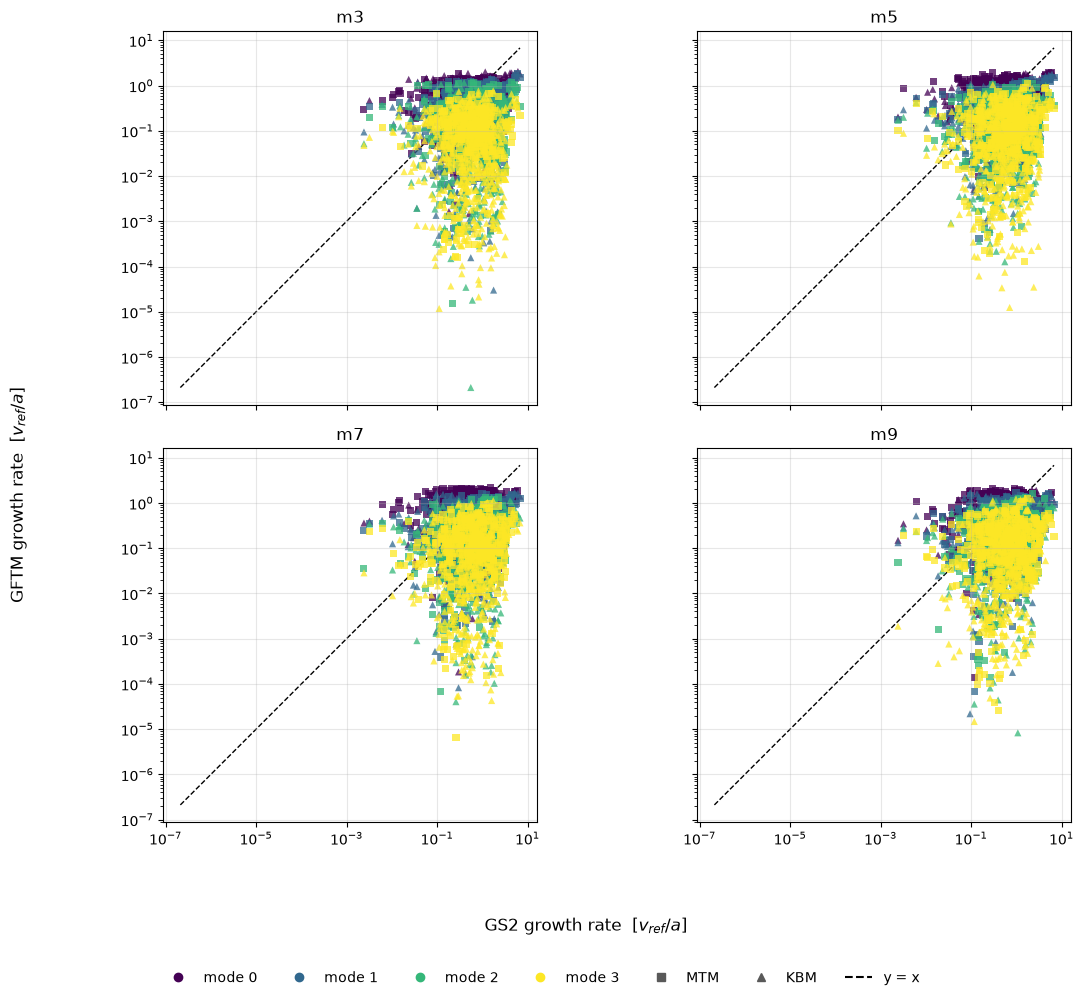

[note] dropped 1647 of 14822 rows with a non-positive growth rate
[note] 'ky' is constant at 0.70241 -- the colour axis carries no information for this dataset


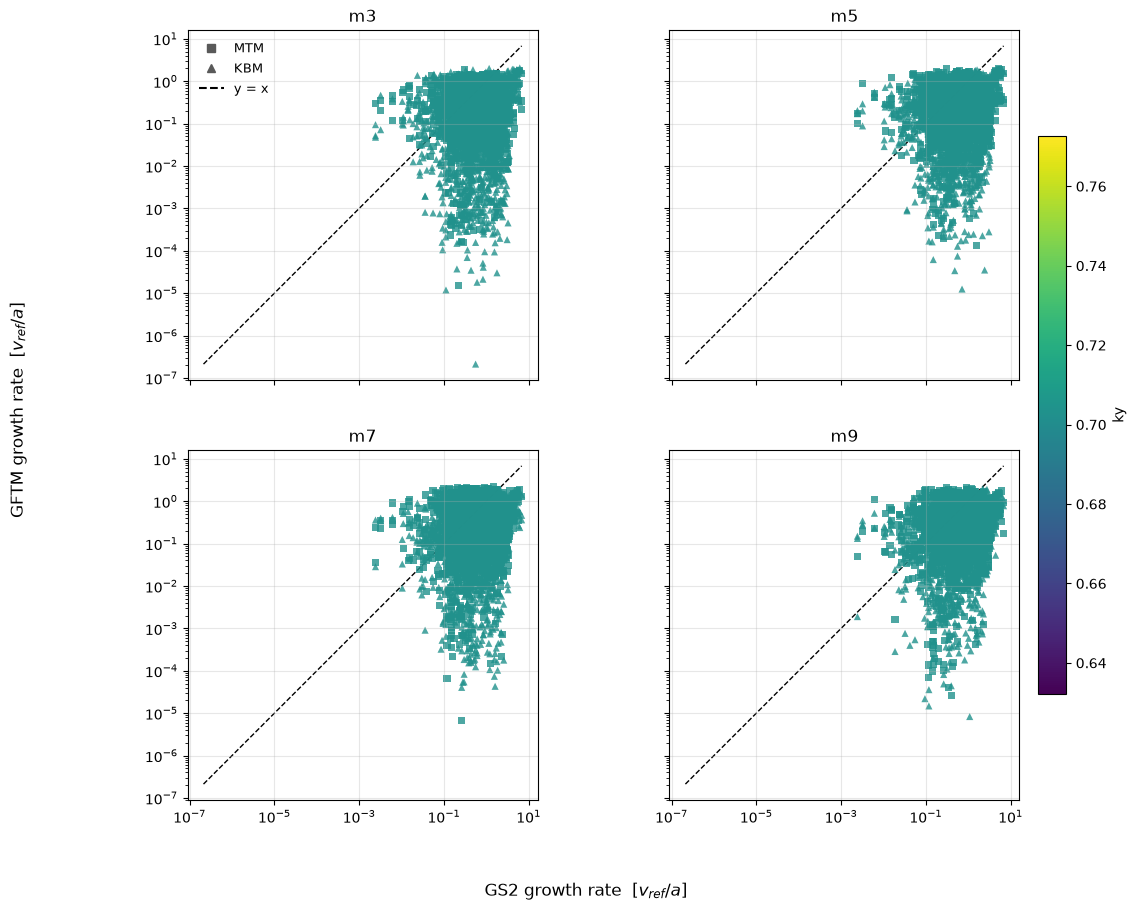

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
from matplotlib.lines import Line2D

PARITY_MARKER = {"MTM": "s", "KBM": "^"}
  

def _positive(df):
    """Log axes silently drop non-positive points -- cut them explicitly and say so."""
    keep = (df["gs2_gamma"] > 0) & (df["gftm_gamma"] > 0)
    if (~keep).any():
        print(f"[note] dropped {(~keep).sum()} of {len(df)} rows with a non-positive growth rate")
    return df[keep]


def _finish(ax, lims, version, logscale):
    ax.plot(lims, lims, "--", color="black", lw=1, zorder=0)
    ax.set_title(version)
    ax.grid(True, alpha=0.3)
    if logscale:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_aspect("equal", adjustable="box")


def plot_all_modes_by_mode(df, versions, figsize=(12, 10), logscale=True, cmap="viridis"):
    """Every mode plotted: colour = mode index, square = MTM, triangle = KBM."""
    if logscale:
        df = _positive(df)

    modes   = np.sort(df["mode"].unique())
    palette = plt.get_cmap(cmap, len(modes))
    colours = {mode: palette(i) for i, mode in enumerate(modes)}   # fixed across panels

    lims = [min(df["gs2_gamma"].min(), df["gftm_gamma"].min()),
            max(df["gs2_gamma"].max(), df["gftm_gamma"].max())]

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True)

    for ax, version in zip(axes.ravel(), versions):
        sub = df[df["version"] == version]

        for mode in modes:
            for parity, marker in PARITY_MARKER.items():
                sel = sub[(sub["mode"] == mode) & (sub["parity"] == parity)]
                if sel.empty:
                    continue
                ax.scatter(sel["gs2_gamma"], sel["gftm_gamma"],
                            marker=marker, color=colours[mode],
                            s=26, alpha=0.75, edgecolors="none")

        _finish(ax, lims, version, logscale)

    handles  = [Line2D([], [], ls="", marker="o", color=colours[m], label=f"mode {m}") for m in modes]
    handles += [Line2D([], [], ls="", marker=mk, color="0.35", label=p) for p, mk in PARITY_MARKER.items()]
    handles += [Line2D([], [], ls="--", color="black", label="y = x")]

    fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False)
    fig.supxlabel("GS2 growth rate  [$v_{ref}/a$]", y=0.06)
    fig.supylabel("GFTM growth rate  [$v_{ref}/a$]")
    fig.tight_layout(rect=(0.02, 0.10, 1, 1))
    return fig


def plot_all_modes_by_value(df, versions, colour_by="ky", figsize=(12, 10),
                            logscale=True, log_colour=False, cmap="viridis"):
    """Same points, but the colour axis carries `colour_by` instead of the mode index."""
    if logscale:
        df = _positive(df)

    vals = df[colour_by].to_numpy(dtype=float)
    if np.allclose(vals, vals[0]):
        print(f"[note] '{colour_by}' is constant at {vals[0]:.5g} -- "
            "the colour axis carries no information for this dataset")

    norm = (LogNorm(vals.min(), vals.max()) if log_colour
            else Normalize(vals.min(), vals.max()))

    lims = [min(df["gs2_gamma"].min(), df["gftm_gamma"].min()),
            max(df["gs2_gamma"].max(), df["gftm_gamma"].max())]

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True)

    for ax, version in zip(axes.ravel(), versions):
        sub = df[df["version"] == version]

        for parity, marker in PARITY_MARKER.items():
            sel = sub[sub["parity"] == parity]
            if sel.empty:
                continue
            ax.scatter(sel["gs2_gamma"], sel["gftm_gamma"], c=sel[colour_by],
                        cmap=cmap, norm=norm, marker=marker,
                        s=26, alpha=0.8, edgecolors="none")

        _finish(ax, lims, version, logscale)

    handles  = [Line2D([], [], ls="", marker=mk, color="0.35", label=p) for p, mk in PARITY_MARKER.items()]
    handles += [Line2D([], [], ls="--", color="black", label="y = x")]
    axes.ravel()[0].legend(handles=handles, loc="upper left", frameon=False, fontsize=9)

    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes,
                label=colour_by, fraction=0.03, pad=0.02)
    fig.supxlabel("GS2 growth rate  [$v_{ref}/a$]")
    fig.supylabel("GFTM growth rate  [$v_{ref}/a$]")
    return fig


fig_modes = plot_all_modes_by_mode(modes_df, gftm_version)
plt.show()

fig_ky = plot_all_modes_by_value(modes_df, gftm_version, colour_by="ky")
plt.show()